# Environment Setup and Importing Libraries

In [2]:
!pip install pycaret[full] --quiet
print("Succefully installed")

Succefully installed


In [4]:
!pip install missingno

In [12]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


print("All libraries imported successfully!")

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

# Configaration and Path Setup

In [7]:
# Define your file paths
url = 'https://raw.githubusercontent.com/irungus/Dessertation/main/Final_Data.csv'

print("Configuration setup complete!")

Configuration setup complete!


# Load and Explore Species Data

In [8]:
df = pd.read_csv(CSV_FILE_PATH)
print(f"Data loaded successfully! Shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nSpecies distribution:")
print(df['species'].value_counts())


NameError: name 'pd' is not defined

# Data Exploration

In [ ]:
# To drop a single column named 'column_name'
df = df.drop(columns=['uid'])

<Axes: >

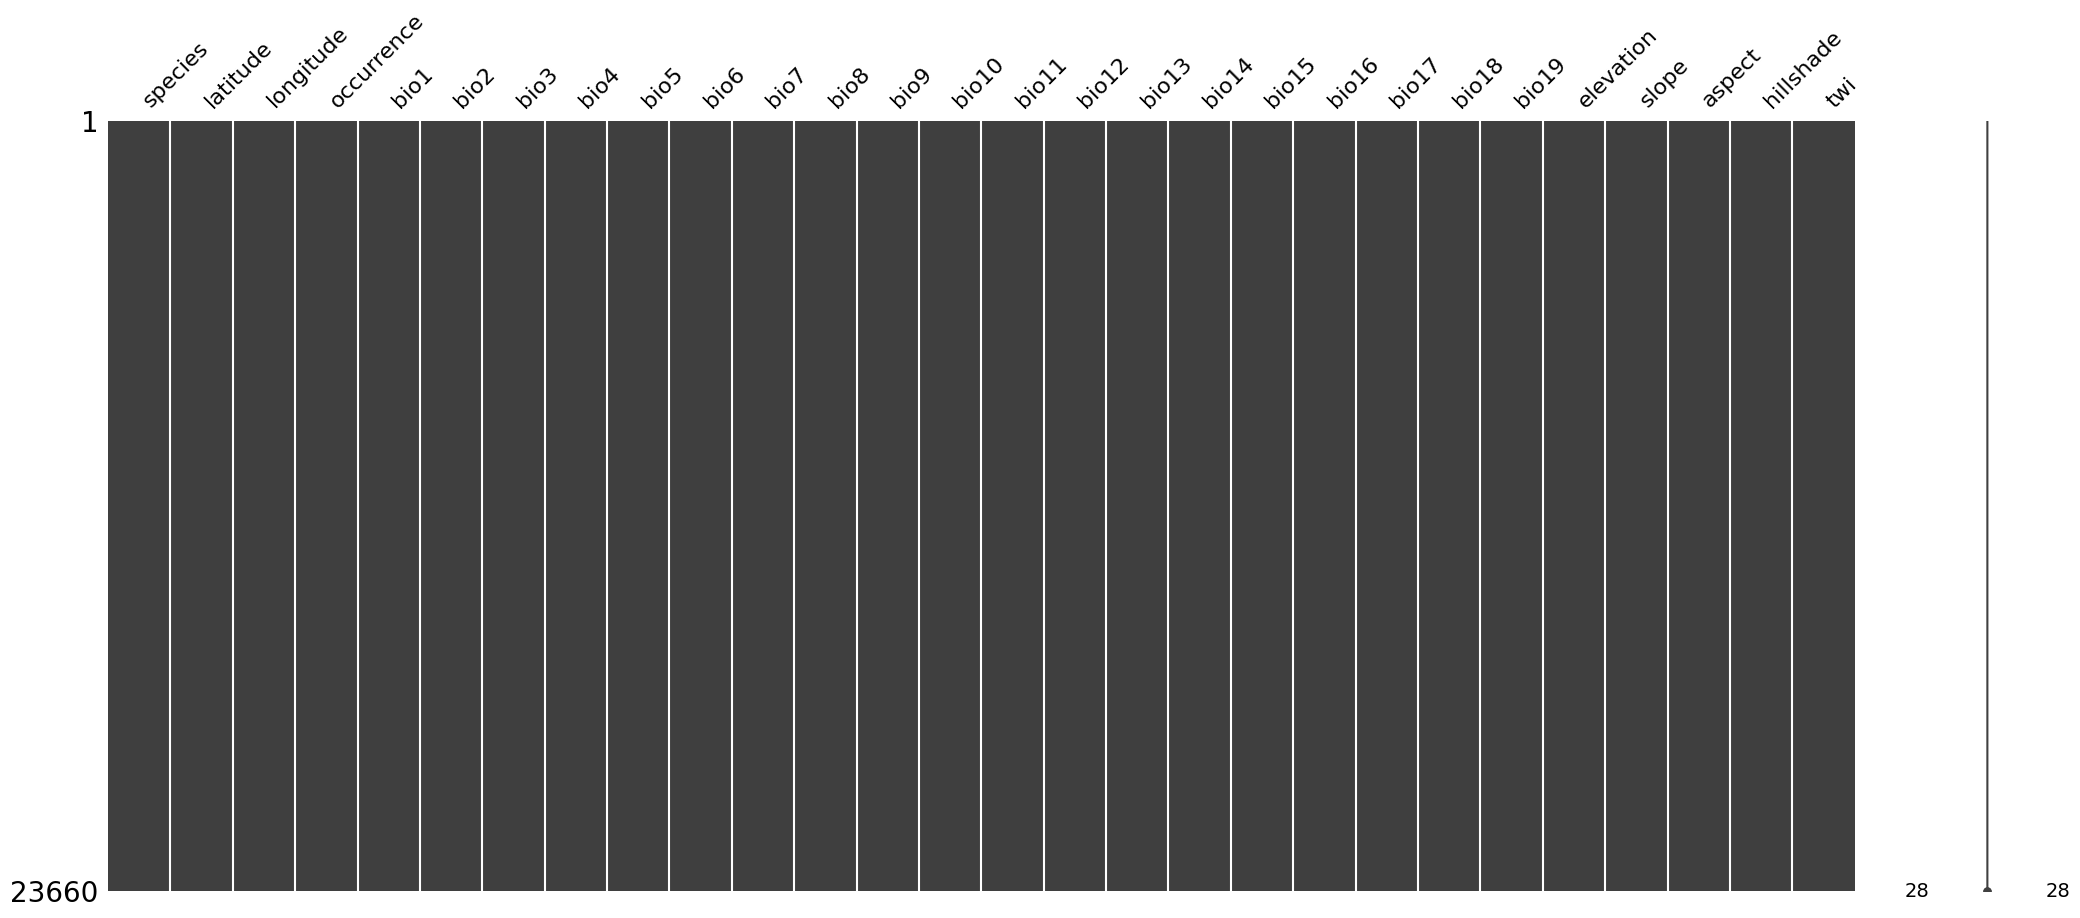

In [ ]:
#Check for missing values
msno.matrix(df)

In [ ]:
# Check for missing values in each column
missing_values_count = df.isnull().sum()

# Print the result
print("Number of missing values per column:")
print(missing_values_count)

Number of missing values per column:
species        0
latitude       0
longitude      0
occurrence     0
bio1           0
bio2           0
bio3           0
bio4           0
bio5           0
bio6           0
bio7           0
bio8           0
bio9           0
bio10          0
bio11          0
bio12          0
bio13          0
bio14          0
bio15          0
bio16          0
bio17          0
bio18          0
bio19          0
elevation      0
slope         24
aspect        24
hillshade     24
twi           24
dtype: int64


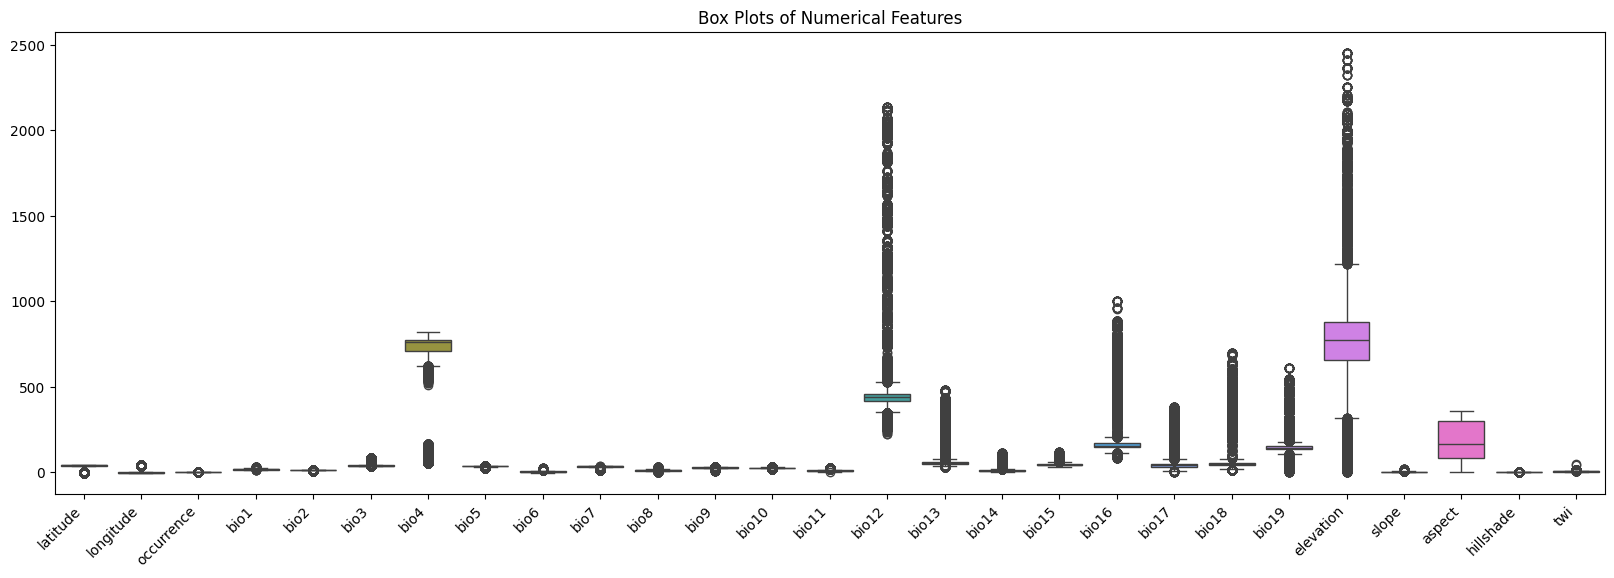

In [ ]:
#Check if there are outliers
plt.figure(figsize=(20, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45, ha='right')
plt.title('Box Plots of Numerical Features')
plt.show()

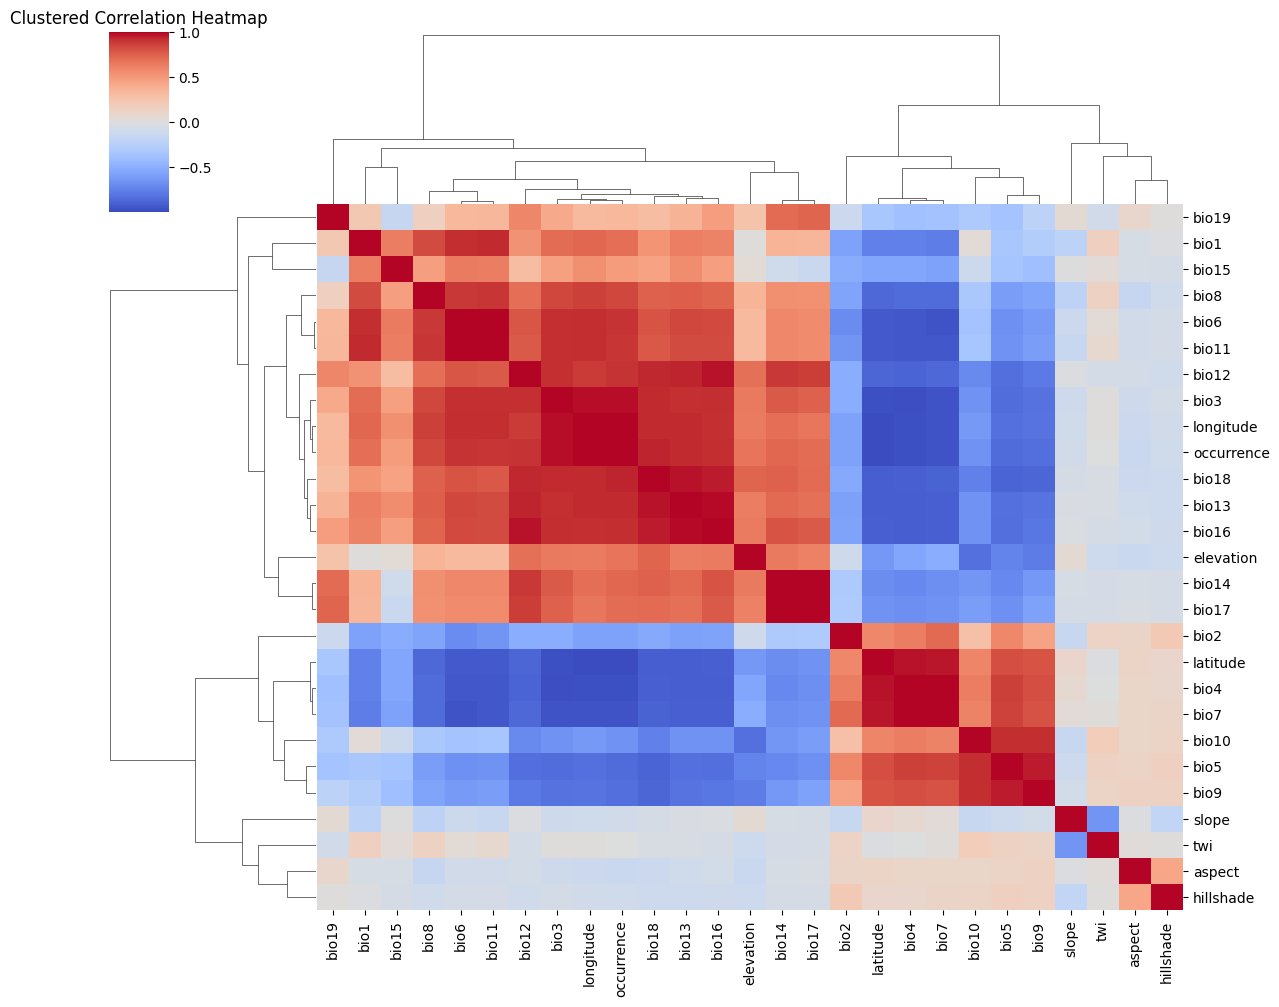

In [ ]:
# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=np.number).columns
df_numeric = df[numeric_cols]

# Calculate the correlation matrix
correlation_matrix = df_numeric.corr()

sns.clustermap(correlation_matrix, cmap='coolwarm', figsize=(12, 10), annot=False)
plt.title('Clustered Correlation Heatmap')
plt.show()

<Figure size 1200x1000 with 0 Axes>

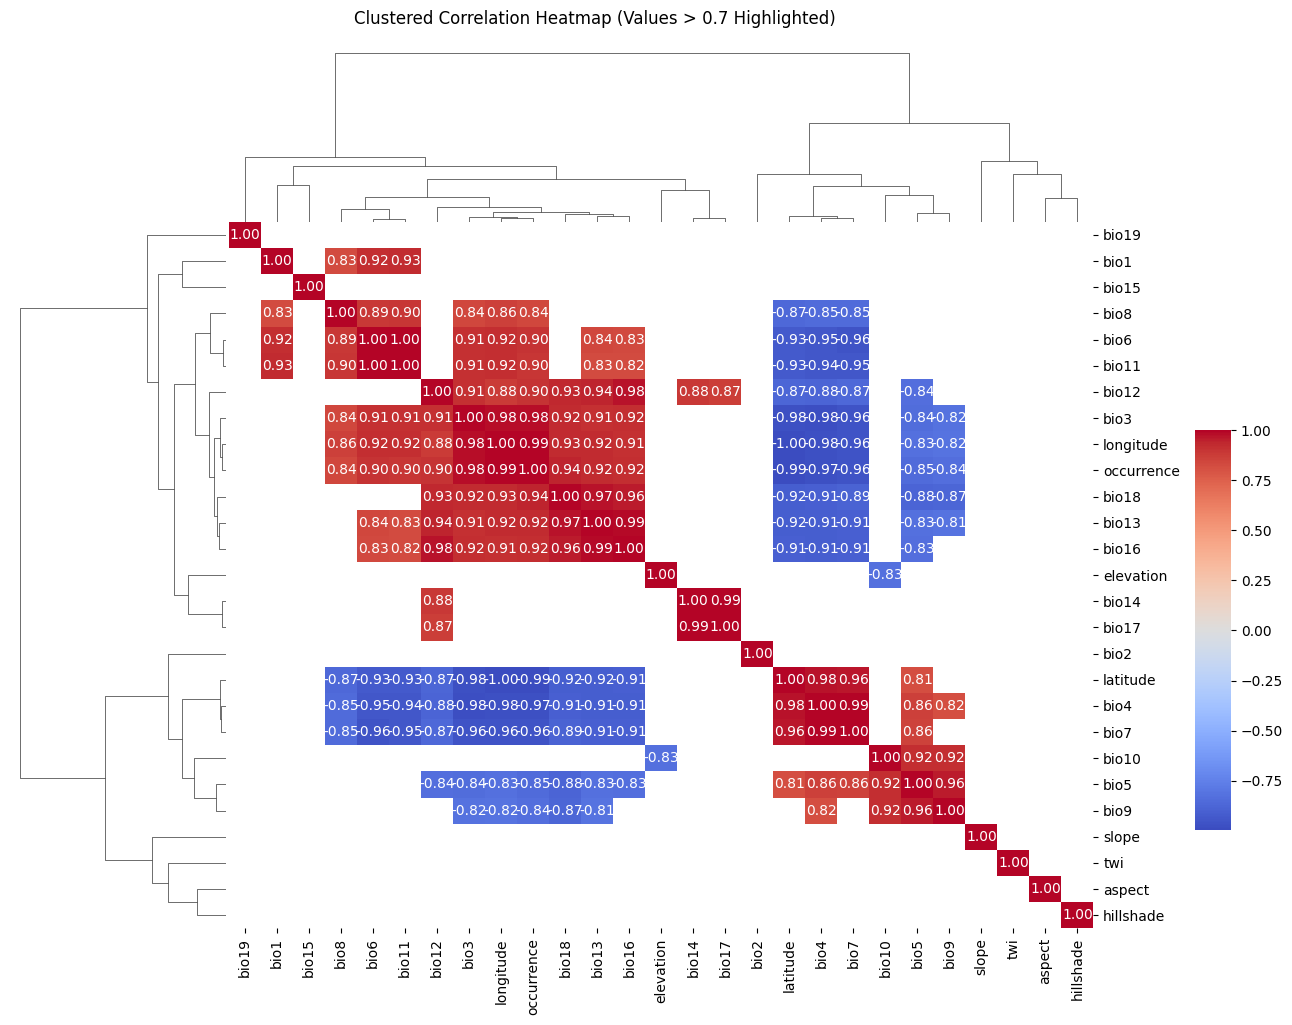

In [ ]:
# 1. Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=np.number).columns
df_numeric = df[numeric_cols]

# 2. Calculate the correlation matrix
correlation_matrix = df_numeric.corr()

# 3. Create a mask to highlight values
# We'll show values with an absolute correlation greater than 0.7
mask = np.abs(correlation_matrix) >= 0.8

# 4. Create the clustermap with annotations based on the mask
plt.figure(figsize=(12, 10))
sns.clustermap(
    correlation_matrix,
    cmap='coolwarm',
    figsize=(12, 10),
    annot=True,  # Set to True to display values
    fmt=".2f",
    mask=~mask, # Use the inverse of the mask to hide values <= 0.7
    cbar_pos=(1.0, 0.2, 0.03, 0.4) # Adjust color bar position if needed
)
plt.suptitle('Clustered Correlation Heatmap (Values > 0.7 Highlighted)', y=1.02)
plt.show()

In [ ]:
# 1. Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=np.number).columns
df_numeric = df[numeric_cols]

# 2. Calculate the correlation matrix
correlation_matrix = df_numeric.corr()

# 3. Unstack the correlation matrix to get a list of all pairs
# and sort them by absolute value
correlation_pairs = correlation_matrix.unstack().sort_values(kind="quicksort", ascending=False)

# 4. Filter for high correlations
# We'll filter for correlations that are above 0.7 (but not 1.0, which is self-correlation)
high_correlations = correlation_pairs[
    (correlation_pairs > 0.8) & (correlation_pairs < 1.0)
]


# This is useful if your variable names are long
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# 5. Print the list of highly correlated pairs
print("Highly Correlated Variable Pairs (absolute value > 0.7):")
print(high_correlations)

Highly Correlated Variable Pairs (absolute value > 0.7):
bio6        bio11         0.995939
bio11       bio6          0.995939
occurrence  longitude     0.993220
longitude   occurrence    0.993220
bio4        bio7          0.992836
                            ...   
bio16       bio11         0.823909
bio9        bio4          0.819070
bio4        bio9          0.819070
bio5        latitude      0.813987
latitude    bio5          0.813987
Length: 106, dtype: float64
